/tmp/ipykernel_17889/1701570953.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download('^NSEI', start='2016-01-01', end='2026-06-01')
[*********************100%***********************]  1 of 1 completed

Harvesting historical data from the exchange... Please wait...

--- Asset Pipeline Successfully Aligned! ---
Total historical trading pool: 2561 days.
Price             Close Log_Returns
Ticker            ^NSEI            
Date                               
2016-01-05  7784.649902   -0.085387
2016-01-06  7741.000000   -0.562296
2016-01-07  7568.299805   -2.256243
2016-01-08  7601.350098    0.435743
2016-01-11  7563.850098   -0.494554


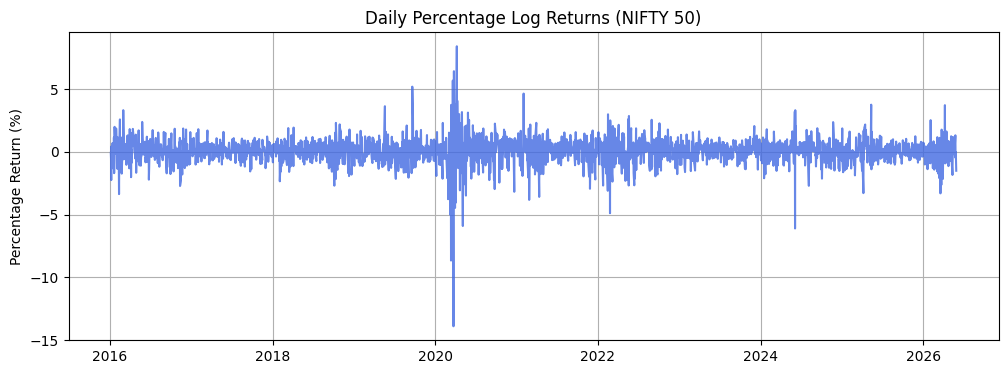

In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Download 10 years of historical daily data for the NIFTY 50 index (^NSEI)
print("Harvesting historical data from the exchange... Please wait...")
nifty_data = yf.download('^NSEI', start='2016-01-01', end='2026-06-01')

# 2. Extract the Close price and calculate daily Log Returns scaled to percentages
nifty_data['Log_Returns'] = np.log(nifty_data['Close'] / nifty_data['Close'].shift(1)) * 100

# 3. Drop the first row containing the NaN artifact from the shift operation
df_garch = nifty_data[['Close', 'Log_Returns']].dropna()

print("\n--- Asset Pipeline Successfully Aligned! ---")
print(f"Total historical trading pool: {len(df_garch)} days.")
print(df_garch.head())

# 4. Quick visual confirmation of Volatility Clustering
plt.figure(figsize=(12, 4))
plt.plot(df_garch.index, df_garch['Log_Returns'], color='royalblue', alpha=0.8)
plt.title('Daily Percentage Log Returns (NIFTY 50)')
plt.ylabel('Percentage Return (%)')
plt.grid(True)
plt.show()

In [4]:
!pip install arch
from arch import arch_model

# 1. Specify the structural parameters of our conditional variance engine
# vol='Garch' sets up the model, p=1 dictates the GARCH lag, q=1 dictates the ARCH lag
garch_blueprint = arch_model(df_garch['Log_Returns'], mean='Constant', vol='Garch', p=1, q=1)

# 2. Fit the model parameters using Maximum Likelihood Estimation (MLE)
garch_fitted = garch_blueprint.fit(disp='off') # disp='off' keeps the terminal printout clean

# 3. Print the complete academic econometric summary table
print(garch_fitted.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.4 MB/s eta 0:00:00
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3242.22
Distribution:                  Normal   AIC:                           6492.44
Method:            Maximum Likelihood   BIC:                           6515.83
                                        No. Observations:                 2561
Date:                Sat, Jun 20 2026   Df Residuals:                     2560
Time:                        16:39:59   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------------------------

=== GARCH Value-at-Risk Calibration Complete ===
Total trading days evaluated: 2561
Number of historical risk breaches: 122
Empirical breach ratio: 4.76% (Target: 5.00%)


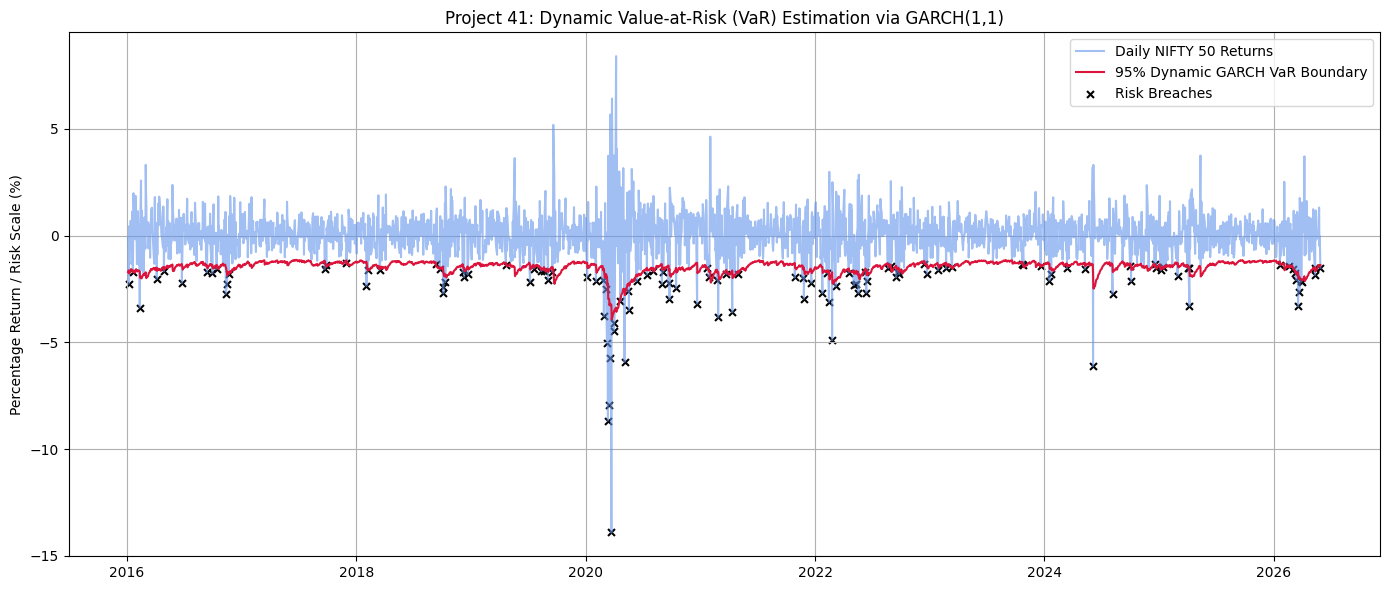

In [5]:
# 1. Extract the conditional volatility (sigma_t) estimated by the GARCH model
# The package outputs variance, so we take the square root to get standard deviation
df_garch['GARCH_Volatility'] = np.sqrt(garch_fitted.conditional_volatility)

# 2. Extract our estimated constant mean (mu) from the model results
mu_estimated = garch_fitted.params['mu']

# 3. Calculate the 95% Dynamic Value-at-Risk boundary
df_garch['VaR_95'] = mu_estimated - 1.645 * df_garch['GARCH_Volatility']

# 4. Count the historical breaches (where actual returns dropped below our forecast VaR)
breaches = df_garch[df_garch['Log_Returns'] < df_garch['VaR_95']]
breach_ratio = len(breaches) / len(df_garch) * 100

print("=== GARCH Value-at-Risk Calibration Complete ===")
print(f"Total trading days evaluated: {len(df_garch)}")
print(f"Number of historical risk breaches: {len(breaches)}")
print(f"Empirical breach ratio: {breach_ratio:.2f}% (Target: 5.00%)")

# 5. Plot the Dynamic VaR overlay
plt.figure(figsize=(14, 6))
plt.plot(df_garch.index, df_garch['Log_Returns'], color='cornflowerblue', alpha=0.6, label='Daily NIFTY 50 Returns')
plt.plot(df_garch.index, df_garch['VaR_95'], color='crimson', linewidth=1.5, label='95% Dynamic GARCH VaR Boundary')
plt.scatter(breaches.index, breaches['Log_Returns'], color='black', marker='x', s=25, label='Risk Breaches')
plt.title('Project 41: Dynamic Value-at-Risk (VaR) Estimation via GARCH(1,1)')
plt.ylabel('Percentage Return / Risk Scale (%)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()